In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df.shape

(119390, 32)

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df['children'] = df['children'].fillna(0)
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)
df['country'] = df['country'].fillna('Unknown')

df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df['arrival_date'] = pd.to_datetime(df['arrival_date_year'].astype(str) + '-' +
                                   df['arrival_date_month'] + '-' +
                                   df['arrival_date_day_of_month'].astype(str))
df['day_of_week'] = df['arrival_date'].dt.dayofweek
df['month'] = df['arrival_date'].dt.month
df['season'] = df['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                3: 'Spring', 4: 'Spring', 5: 'Spring',
                                6: 'Summer', 7: 'Summer', 8: 'Summer',
                                9: 'Fall', 10: 'Fall', 11: 'Fall'})

In [ ]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_high_season'] = df['month'].isin([6, 7, 8, 12]).astype(int)
df['booking_lead_category'] = pd.cut(df['lead_time'],
                                    bins=[0, 7, 30, 90, 365],
                                    labels=['Last_minute', 'Short', 'Medium', 'Long'])

In [ ]:
df = df[df['adr'] >= 0]
df = df[df['total_guests'] > 0]
df = df[df['total_nights'] > 0]
df = df[df['adr'] <= 1000]

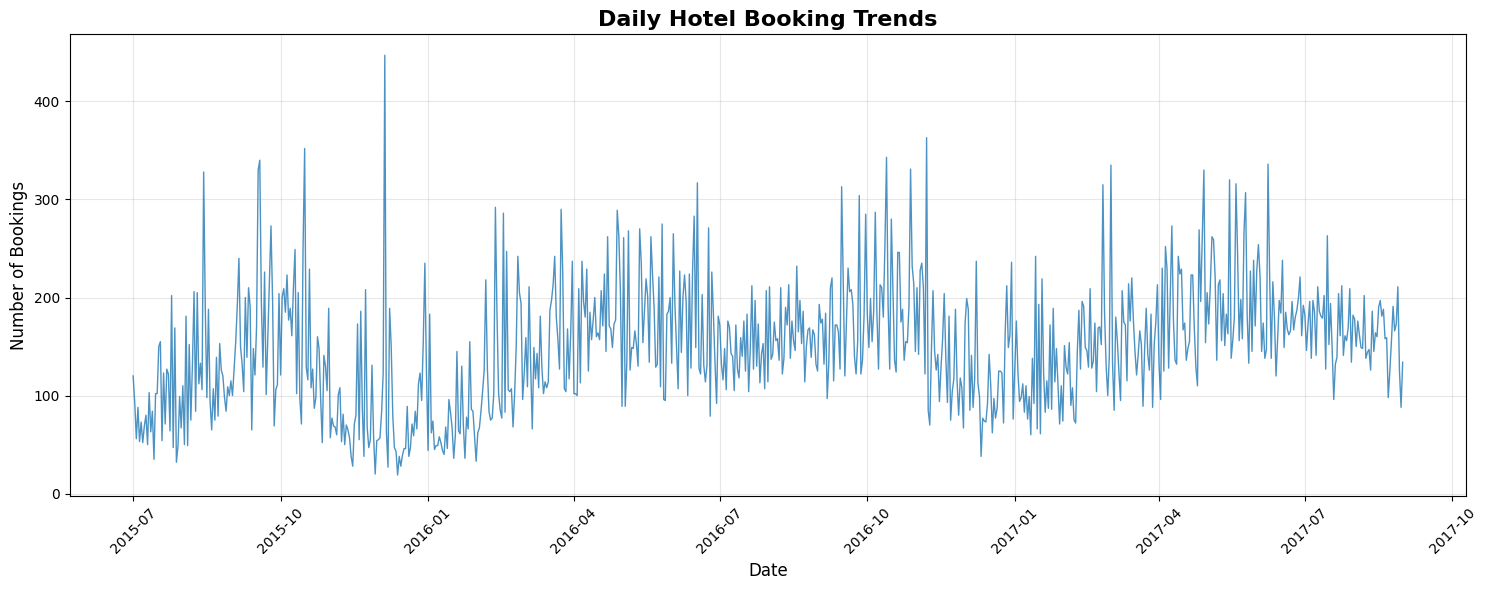

In [ ]:
daily_bookings = df.groupby('arrival_date').size().reset_index(name='bookings')
plt.figure(figsize=(15, 6))
plt.plot(daily_bookings['arrival_date'], daily_bookings['bookings'], linewidth=1, alpha=0.8)
plt.title('Daily Hotel Booking Trends', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

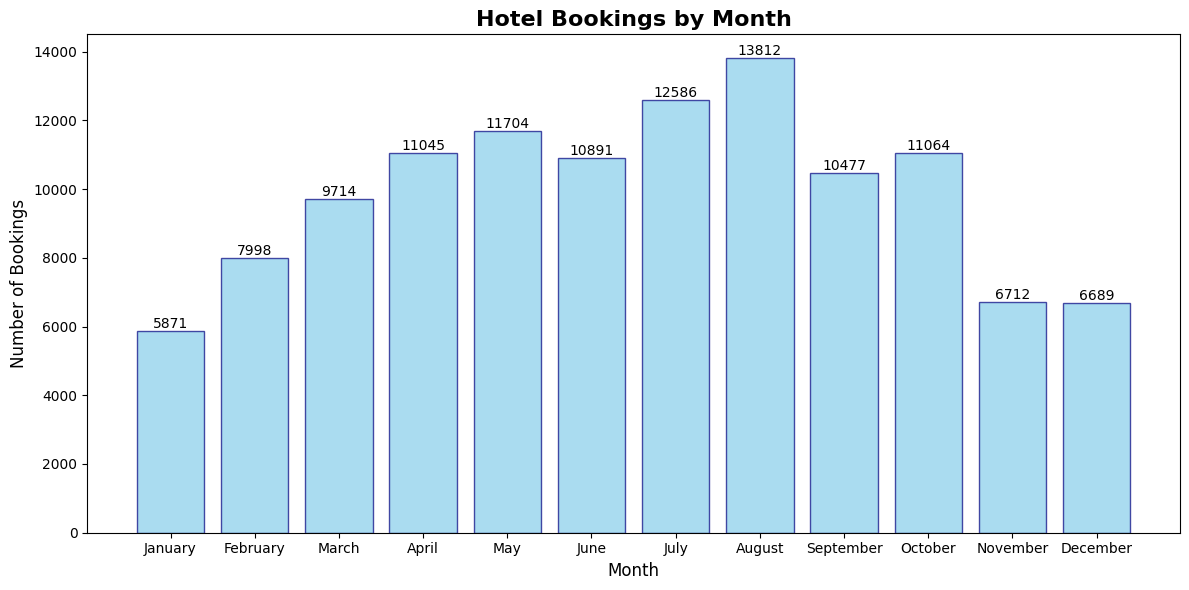

In [ ]:
monthly_bookings = df.groupby('arrival_date_month').size().reset_index(name='bookings')
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_bookings['arrival_date_month'] = pd.Categorical(monthly_bookings['arrival_date_month'], categories=month_order, ordered=True)
monthly_bookings = monthly_bookings.sort_values('arrival_date_month')

plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_bookings['arrival_date_month'], monthly_bookings['bookings'],
               color='skyblue', edgecolor='navy', alpha=0.7)
plt.title('Hotel Bookings by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.xticks(rotation=0)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

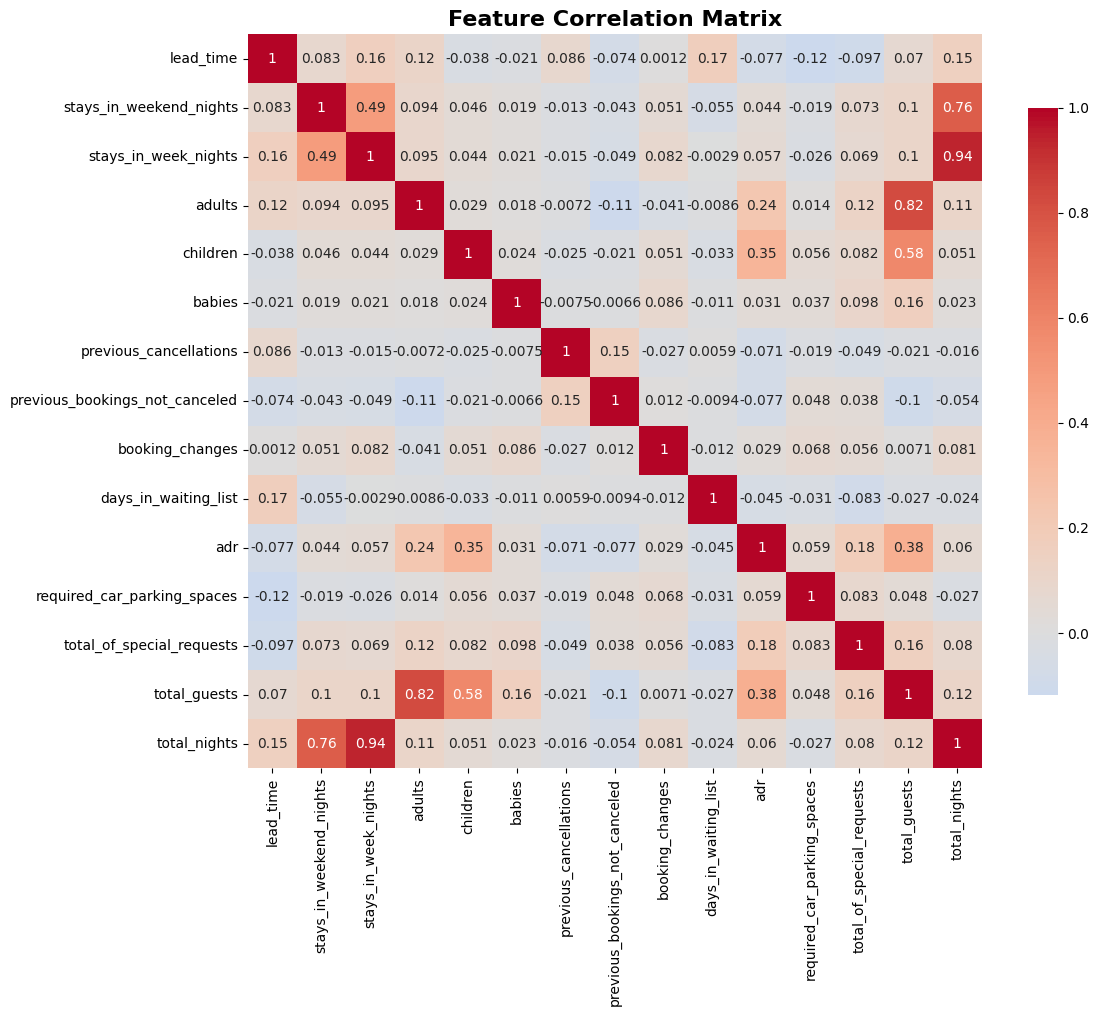

In [ ]:
numeric_features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
                   'adults', 'children', 'babies', 'previous_cancellations',
                   'previous_bookings_not_canceled', 'booking_changes',
                   'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
                   'total_of_special_requests', 'total_guests', 'total_nights']

correlation_matrix = df[numeric_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
rl_data = df[['arrival_date', 'adr', 'is_canceled', 'lead_time', 'total_guests',
              'total_nights', 'is_weekend', 'is_high_season', 'day_of_week', 'month']].copy()
rl_data = rl_data.sort_values('arrival_date').reset_index(drop=True)
rl_data['date_index'] = range(len(rl_data))
rl_data.head()

,arrival_date,adr,is_canceled,lead_time,total_guests,total_nights,is_weekend,is_high_season,day_of_week,month,date_index
0,2015-07-01,75.0,0,7,1.0,1,0,1,2,7,0
1,2015-07-01,80.0,0,257,1.0,2,0,1,2,7,1
2,2015-07-01,101.5,0,257,2.0,2,0,1,2,7,2
3,2015-07-01,101.5,0,257,2.0,2,0,1,2,7,3
4,2015-07-01,101.5,0,257,2.0,2,0,1,2,7,4


In [ ]:
class HotelPricingEnvironment:
    def __init__(self, data, initial_rooms=100):
        self.data = data.copy()
        self.initial_rooms = initial_rooms
        self.current_step = 0
        self.max_steps = len(data) - 1
        self.reset()

    def reset(self):
        self.current_step = 0
        self.available_rooms = self.initial_rooms
        self.total_revenue = 0
        self.bookings_made = 0
        return self._get_state()

    def _get_state(self):
        if self.current_step >= len(self.data):
            return np.array([0, 0, 0, 0, 0, 0])

        row = self.data.iloc[self.current_step]
        state = np.array([
            self.available_rooms / self.initial_rooms,
            row['total_guests'] / 10.0,
            row['total_nights'] / 7.0,
            row['is_weekend'],
            row['is_high_season'],
            row['lead_time'] / 365.0
        ])
        return state

    def step(self, action):
        if self.current_step >= self.max_steps:
            return self._get_state(), 0, True, {}

        row = self.data.iloc[self.current_step]
        price_multiplier = 0.5 + (action * 0.1)
        base_price = 100
        suggested_price = base_price * price_multiplier

        demand_probability = self._calculate_demand_probability(suggested_price, row)
        booking_made = np.random.random() < demand_probability

        reward = 0
        if booking_made and self.available_rooms > 0:
            rooms_needed = min(row['total_guests'], self.available_rooms)
            revenue = suggested_price * rooms_needed * row['total_nights']
            self.total_revenue += revenue
            self.available_rooms -= rooms_needed
            self.bookings_made += 1
            reward = revenue / 1000.0
        elif not booking_made:
            reward = -1
        else:
            reward = -5

        self.current_step += 1
        done = self.current_step >= self.max_steps

        return self._get_state(), reward, done, {'revenue': self.total_revenue}

    def _calculate_demand_probability(self, price, row):
        base_prob = 0.6

        if price > 200:
            base_prob *= 0.3
        elif price > 150:
            base_prob *= 0.6
        elif price < 80:
            base_prob *= 1.2

        if row['is_weekend']:
            base_prob *= 1.3
        if row['is_high_season']:
            base_prob *= 1.4
        if row['lead_time'] < 7:
            base_prob *= 0.8

        return min(base_prob, 1.0)

In [ ]:
class QLearningAgent:
    def __init__(self, state_size=6, action_size=10, learning_rate=0.1,
                 discount_factor=0.95, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.q_table = {}

    def _get_state_key(self, state):
        return tuple(np.round(state, 2))

    def _get_q_value(self, state, action):
        state_key = self._get_state_key(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_size)
        return self.q_table[state_key][action]

    def _set_q_value(self, state, action, value):
        state_key = self._get_state_key(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.action_size)
        self.q_table[state_key][action] = value

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_size)

        state_key = self._get_state_key(state)
        if state_key not in self.q_table:
            return np.random.randint(self.action_size)

        return np.argmax(self.q_table[state_key])

    def learn(self, state, action, reward, next_state, done):
        current_q = self._get_q_value(state, action)

        if done:
            target_q = reward
        else:
            next_state_key = self._get_state_key(next_state)
            if next_state_key in self.q_table:
                next_max_q = np.max(self.q_table[next_state_key])
            else:
                next_max_q = 0
            target_q = reward + self.discount_factor * next_max_q

        new_q = current_q + self.learning_rate * (target_q - current_q)
        self._set_q_value(state, action, new_q)

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [ ]:
env = HotelPricingEnvironment(rl_data)
agent = QLearningAgent()

episodes = 500
rewards_per_episode = []
revenue_per_episode = []

for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    while True:
        action = agent.choose_action(state)
        next_state, reward, done, info = env.step(action)
        agent.learn(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        if done:
            break

    rewards_per_episode.append(total_reward)
    revenue_per_episode.append(info['revenue'])

    if episode % 100 == 0:
        print(f"Episode {episode}, Total Reward: {total_reward:.2f}, Revenue: {info['revenue']:.2f}, Epsilon: {agent.epsilon:.3f}")

Episode 0, Total Reward: -475739.27, Revenue: 25730.00, Epsilon: 0.010
Episode 100, Total Reward: -467918.65, Revenue: 22350.00, Epsilon: 0.010
Episode 200, Total Reward: -466336.96, Revenue: 23040.00, Epsilon: 0.010
Episode 300, Total Reward: -464992.83, Revenue: 24170.00, Epsilon: 0.010
Episode 400, Total Reward: -463274.17, Revenue: 22830.00, Epsilon: 0.010


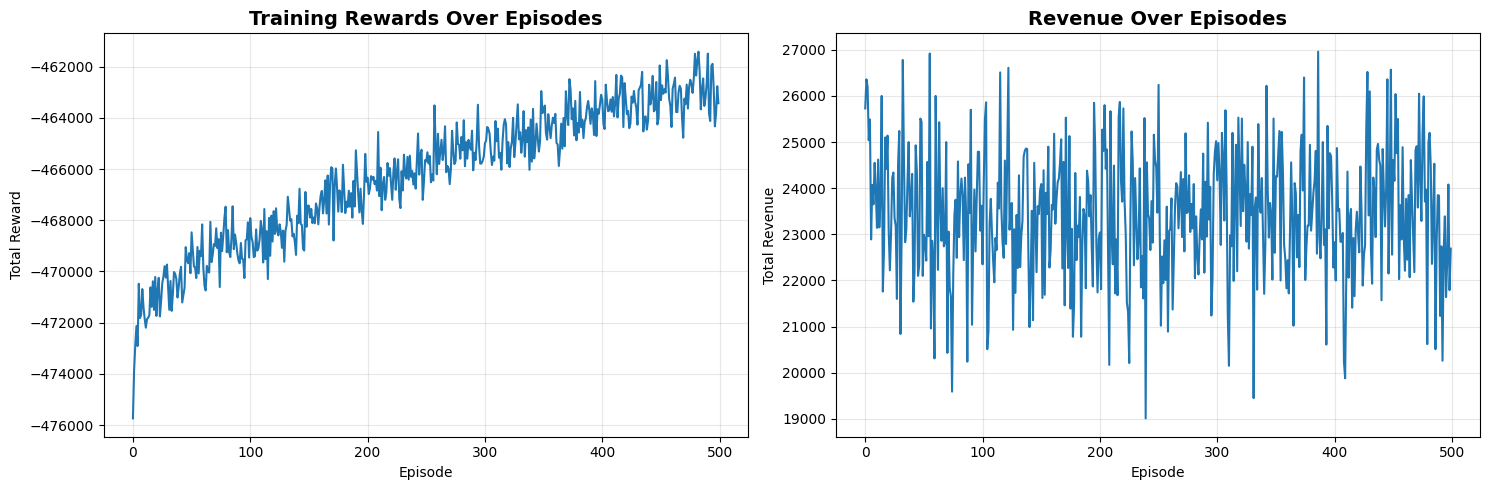

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode)
plt.title('Training Rewards Over Episodes', fontsize=14, fontweight='bold')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(revenue_per_episode)
plt.title('Revenue Over Episodes', fontsize=14, fontweight='bold')
plt.xlabel('Episode')
plt.ylabel('Total Revenue')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
test_env = HotelPricingEnvironment(rl_data)
agent.epsilon = 0
state = test_env.reset()
actions_taken = []
revenues_generated = []
prices_set = []

while True:
    action = agent.choose_action(state)
    next_state, reward, done, info = test_env.step(action)

    price = 100 * (0.5 + action * 0.1)
    actions_taken.append(action)
    prices_set.append(price)
    revenues_generated.append(info['revenue'])

    state = next_state
    if done:
        break

print(f"Final Revenue: ${test_env.total_revenue:.2f}")
print(f"Total Bookings: {test_env.bookings_made}")
print(f"Average Price: ${np.mean(prices_set):.2f}")